Сделано с асгардархеей.

In [1]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00


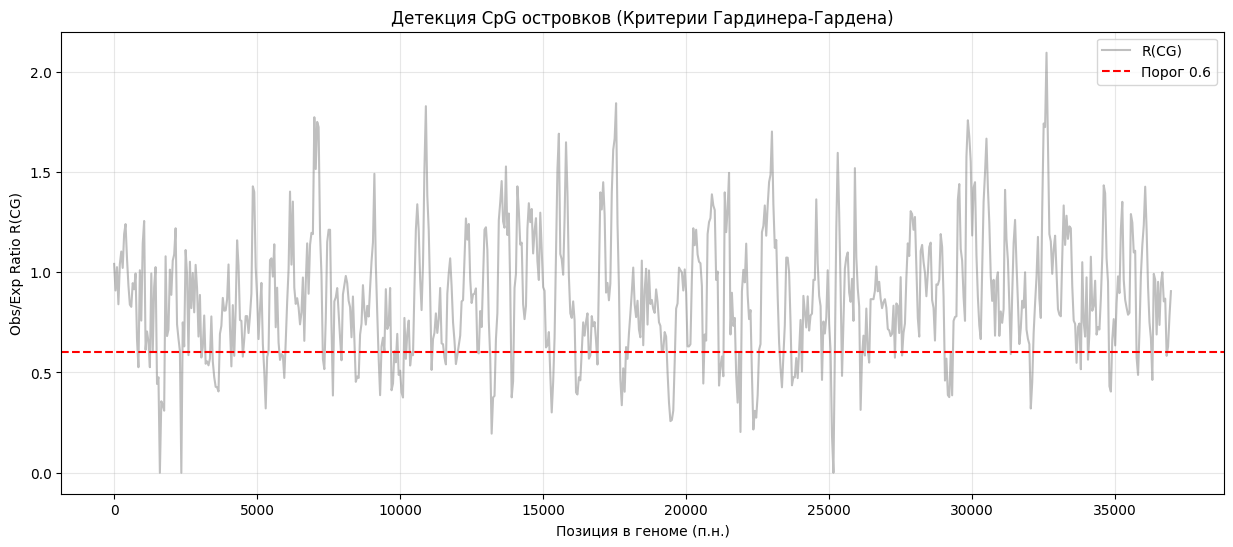

Найдено потенциальных CpG участков: 0


In [14]:
from Bio import SeqIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

record = next(SeqIO.parse("gen.fna", "fasta"))
seq = str(record.seq[:100000]).upper()

def compute_cpg_metrics(window):
    w_len = len(window)
    if w_len == 0: return 0, 0

    count_c = window.count('C')
    count_g = window.count('G')
    count_cg = window.count('CG')

    p_c = count_c / w_len
    p_g = count_g / w_len

    if count_c > 0 and count_g > 0:
        r_cg = (count_cg * w_len) / (count_c * count_g)
    else:
        r_cg = 0

    gc_percent = (count_c + count_g) / w_len * 100

    return r_cg, gc_percent

window_size = 200
step = 50
positions = []
r_values = []
gc_values = []
is_island = []

for i in range(0, len(seq) - window_size, step):
    window = seq[i : i + window_size]
    r, gc = compute_cpg_metrics(window)

    positions.append(i)
    r_values.append(r)
    gc_values.append(gc)

    if r > 0.6 and gc > 50:
        is_island.append(i)

plt.figure(figsize=(15, 6))

plt.plot(positions, r_values, color='gray', alpha=0.5, label='R(CG) ratio')
plt.axhline(y=0.6, color='red', linestyle='--', label='Порог 0.6')

for pos in is_island:
    plt.axvspan(pos, pos + window_size, color='green', alpha=0.3)

plt.title("Детекция CpG островков (Критерии Гардинера-Гардена)")
plt.xlabel("Позиция в геноме (п.н.)")
plt.ylabel("Obs/Exp Ratio R(CG)")
plt.legend(['R(CG)', 'Порог 0.6', 'Найденный CpG остров'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"Найдено потенциальных CpG участков: {len(is_island)}")